# Taller Análisis Exploratorio de Datos

## Paso 1: Carga de datos

Abra el archivo en Excel o bloc de notas, y revise sí hay algo particular con los datos. Este paso es importante para evitar problemas posteriores al cargar los datos.

Cargar el archivo dado, que contiene un dataset cuya información puede consultar en [UCI](https://archive.ics.uci.edu/dataset/27/credit+approval).

De a las columnas los siguientes nombres: 'A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15'.

Responda las siguientes preguntas:

- ¿Cuántas filas y columnas tiene el dataframe?
- ¿De qué tipo de dato es cada columna?
- ¿Las variables están en el tipo de dato correcto para su contenido?

Abriendo el archivo en el bloc de notas se ve que no trae encabezado, que los datos faltantes están marcados con `?` y que hay números con ceros a la izquierda, como 00202 y 01. Primero lo cargo tal cual, sin ningún parámetro adicional, para ver cómo lo interpreta pandas.

In [63]:
import pandas as pd

df = pd.read_csv(
    'crx.data',
    header=None
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   0       690 non-null    object 
 1   1       690 non-null    object 
 2   2       690 non-null    float64
 3   3       690 non-null    object 
 4   4       690 non-null    object 
 5   5       690 non-null    object 
 6   6       690 non-null    object 
 7   7       690 non-null    float64
 8   8       690 non-null    object 
 9   9       690 non-null    object 
 10  10      690 non-null    int64  
 11  11      690 non-null    object 
 12  12      690 non-null    object 
 13  13      690 non-null    object 
 14  14      690 non-null    int64  
 15  15      690 non-null    object 
dtypes: float64(2), int64(2), object(12)
memory usage: 86.4+ KB


Aquí se confirman dos problemas. El primero es que quedaron 16 columnas y no 15 como dice el enunciado; buscando en UCI, esa columna de más es la clase del dataset (`+` si aprobaron el crédito y `-` si lo negaron), así que le voy a poner A16 para no dejarla por fuera.

El segundo es que dice que no hay ningún dato nulo y que las columnas 1 y 13 son de texto, cuando por el contenido deberían ser numéricas. Eso pasa porque los faltantes vienen escritos como `?` y pandas los está tomando como una categoría más. Vuelvo a cargar el archivo indicándole eso y ya de paso le pongo los nombres a las columnas.

In [64]:
df = pd.read_csv(
    'crx.data',
    header=None,
    names=['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10',
           'A11', 'A12', 'A13', 'A14', 'A15', 'A16'],
    na_values='?'
)

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 690 entries, 0 to 689
Data columns (total 16 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      678 non-null    object 
 1   A2      678 non-null    float64
 2   A3      690 non-null    float64
 3   A4      684 non-null    object 
 4   A5      684 non-null    object 
 5   A6      681 non-null    object 
 6   A7      681 non-null    object 
 7   A8      690 non-null    float64
 8   A9      690 non-null    object 
 9   A10     690 non-null    object 
 10  A11     690 non-null    int64  
 11  A12     690 non-null    object 
 12  A13     690 non-null    object 
 13  A14     677 non-null    float64
 14  A15     690 non-null    int64  
 15  A16     690 non-null    object 
dtypes: float64(4), int64(2), object(10)
memory usage: 86.4+ KB


In [65]:
df.head()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


In [66]:
df.describe()

,A2,A3,A8,A11,A14,A15
count,678.000000,690.000000,690.000000,690.00000,677.000000,690.000000
mean,31.568171,4.758725,2.223406,2.40000,184.014771,1017.385507
std,11.957862,4.978163,3.346513,4.86294,173.806768,5210.102598
min,13.750000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,22.602500,1.000000,0.165000,0.00000,75.000000,0.000000
50%,28.460000,2.750000,1.000000,0.00000,160.000000,5.000000
75%,38.230000,7.207500,2.625000,3.00000,276.000000,395.500000
max,80.250000,28.000000,28.500000,67.00000,2000.000000,100000.000000


In [67]:
df.describe(include='object').T

,count,unique,top,freq
A1,678,2,b,468
A4,684,3,u,519
A5,684,3,g,519
A6,681,14,c,137
A7,681,9,v,399
A9,690,2,t,361
A10,690,2,f,395
A12,690,2,f,374
A13,690,3,g,625
A16,690,2,-,383


El dataframe quedó con 690 filas y 16 columnas. De esas, 6 son numéricas (A2, A3, A8, A11, A14 y A15) y las otras 10 quedaron como object.

Ahora sí los tipos están bien. Comparando con la primera carga se ve la diferencia: A2 y A14 pasaron de texto a numéricas, y ya aparecen los conteos de nulos que antes estaban escondidos detrás de los `?`. A14 se muestra como float en vez de entero, pero es solo porque tiene nulos.

Como los nombres vienen anonimizados, uno puede revisar que el tipo cuadre con el contenido, pero no con el significado real de cada variable.

## Paso 2: Exploración inicial de los datos

Responda las siguientes preguntas:

- ¿Hay valores fuera de rango o imposibles, según el dominio del problema?
- ¿Hay variables que no varían?
- Qué variables *cualitativas* tienen muchos valores únicos (alta cardinalidad)?
- ¿Hay claves primarias o identificadores únicos?

In [68]:
for col in df.select_dtypes(include=['object']).columns:
    print(f'La columna "{col}" tiene las siguientes categorías: \n {df[col].unique()} \n')

La columna "A1" tiene las siguientes categorías: 
 ['b' 'a' nan] 

La columna "A4" tiene las siguientes categorías: 
 ['u' 'y' nan 'l'] 

La columna "A5" tiene las siguientes categorías: 
 ['g' 'p' nan 'gg'] 

La columna "A6" tiene las siguientes categorías: 
 ['w' 'q' 'm' 'r' 'cc' 'k' 'c' 'd' 'x' 'i' 'e' 'aa' 'ff' 'j' nan] 

La columna "A7" tiene las siguientes categorías: 
 ['v' 'h' 'bb' 'ff' 'j' 'z' nan 'o' 'dd' 'n'] 

La columna "A9" tiene las siguientes categorías: 
 ['t' 'f'] 

La columna "A10" tiene las siguientes categorías: 
 ['t' 'f'] 

La columna "A12" tiene las siguientes categorías: 
 ['f' 't'] 

La columna "A13" tiene las siguientes categorías: 
 ['g' 's' 'p'] 

La columna "A16" tiene las siguientes categorías: 
 ['+' '-'] 



In [69]:
df.nunique().sort_values(ascending=False)

A2     349
A15    240
A3     215
A14    170
A8     132
A11     23
A6      14
A7       9
A4       3
A5       3
A13      3
A1       2
A12      2
A10      2
A9       2
A16      2
dtype: int64

Valores imposibles no hay. Todas las numéricas son mayores o iguales a cero, que es lo que uno espera cuando se habla de edades, montos y saldos, y A2 va de 13.75 a 80.25, que cuadra si fuera la edad del solicitante.

Lo que sí hay son valores muy altos comparados con el resto. A15 llega a 100.000 cuando el 75% de los datos no pasa de 396, y A11 llega a 67 con mediana en 0. No son imposibles, son casos raros, y los miro mejor en el Paso 4.

No parece haber claves primarias ni variables constantes: ninguna columna tiene los 690 valores distintos y todas toman al menos dos valores. Se pueden considerar de alta cardinalidad A6, con 14 categorías, y A7, con 9; las demás andan entre 2 y 3.

## Paso 3: Identificación de datos duplicados, datos nulos y problemas de formateo

Descarte las variables que solo toman un valor y las que son clave primaria. También descarte las variables **City** y **Lat Long**.

Responda las siguientes preguntas:

- ¿Qué variables tienen valores nulos? ¿En qué proporción?
- ¿Hay registros duplicados?
- ¿Hay variables con problemas de formateo (fechas, monedas, mayúsculas/minúsculas)?

No hay variables constantes ni clave primaria, y las variables City y Lat Long no están en este dataset, así que no se descarta ninguna columna.

In [70]:
df.isnull().sum().sort_values(ascending=False)

A14    13
A1     12
A2     12
A7      9
A6      9
A5      6
A4      6
A3      0
A8      0
A9      0
A11     0
A10     0
A12     0
A13     0
A15     0
A16     0
dtype: int64

In [71]:
df.isnull().sum().sort_values(ascending=False)*100/df.shape[0]

A14    1.884058
A1     1.739130
A2     1.739130
A7     1.304348
A6     1.304348
A5     0.869565
A4     0.869565
A3     0.000000
A8     0.000000
A9     0.000000
A11    0.000000
A10    0.000000
A12    0.000000
A13    0.000000
A15    0.000000
A16    0.000000
dtype: float64

In [72]:
print('Número de registros duplicados: ', df.duplicated().sum())

Número de registros duplicados:  0


Tienen nulos siete variables y todas en proporciones bajitas: A14 con 1.88%, A1 y A2 con 1.74%, A6 y A7 con 1.30%, y A4 y A5 con 0.87%. Como ninguna llega ni al 2% no hay que botar columnas; para el modelo se pueden imputar con la mediana en las numéricas, porque A2 y A14 son sesgadas y la media quedaría corrida, y con la moda en las categóricas.

Algo curioso es que los nulos de A4 y A5 caen en los mismos registros, y los de A6 y A7 también, o sea que esos campos parece que se llenaban juntos en el formulario.

Registros duplicados no hay, el `duplicated()` da 0. Y viendo las categorías del paso anterior tampoco se ve ningún problema de digitación: no hay fechas ni monedas, y todo el texto está en minúscula. Lo del `?` y lo de los ceros a la izquierda ya se había resuelto desde la carga.

## Paso 4: Análisis de variables cuantitativas

Haga análisis de normalidad de las variables cuantitativas. Indique cuáles variables cumplen con el supuesto de normalidad y cuáles no.

Haga un análisis gráfico de outliers, y como resultado de este indique que variables tienen datos atípicos.

In [73]:
num_vars = df.select_dtypes(include=["number"]).columns
print('Variables numéricas: ', num_vars)

Variables numéricas:  Index(['A2', 'A3', 'A8', 'A11', 'A14', 'A15'], dtype='object')


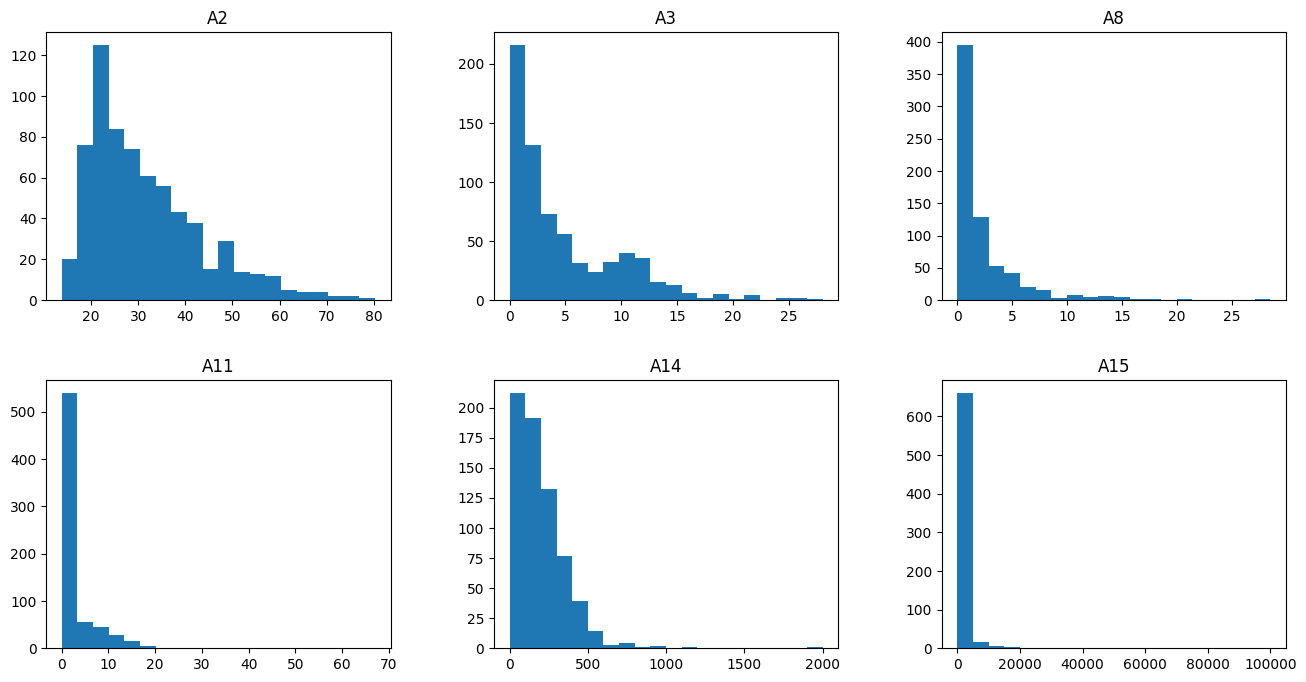

In [74]:
df.hist(figsize=(16, 8), bins=20, layout=(2, 3), grid=False, sharex=False, sharey=False);

In [75]:
df.select_dtypes('number').skew()

A2      1.145892
A3      1.488813
A8      2.891330
A11     5.152520
A14     2.723993
A15    13.140655
dtype: float64

In [76]:
from scipy.stats import kstest

for num in num_vars:
    datos = df[num].dropna()
    __, p_value = kstest(datos, 'norm', args=(datos.mean(), datos.std()))
    print(f'Prueba de Kolmogorov-Smirnov para {num}:')
    print(f'  Valor p: {p_value}')
    if p_value > 0.05:
        print(f'  {num} parece ser normal (no se rechaza la hipótesis nula)\n')
    else:
        print(f'  {num} no parece ser normal (se rechaza la hipótesis nula)\n')

Prueba de Kolmogorov-Smirnov para A2:
  Valor p: 1.0331118517919035e-07
  A2 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A3:
  Valor p: 1.3014031904956555e-18
  A3 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A8:
  Valor p: 1.750811541608802e-39
  A8 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A11:
  Valor p: 1.0376830545783971e-59
  A11 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A14:
  Valor p: 7.328091783236191e-13
  A14 no parece ser normal (se rechaza la hipótesis nula)

Prueba de Kolmogorov-Smirnov para A15:
  Valor p: 2.949727065225186e-112
  A15 no parece ser normal (se rechaza la hipótesis nula)



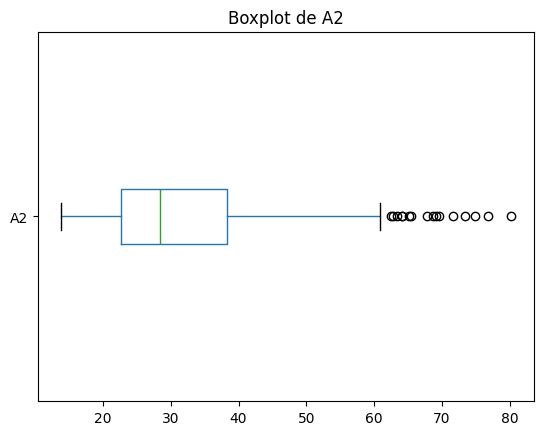

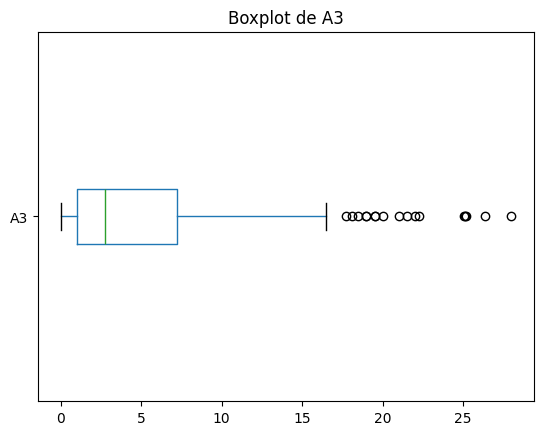

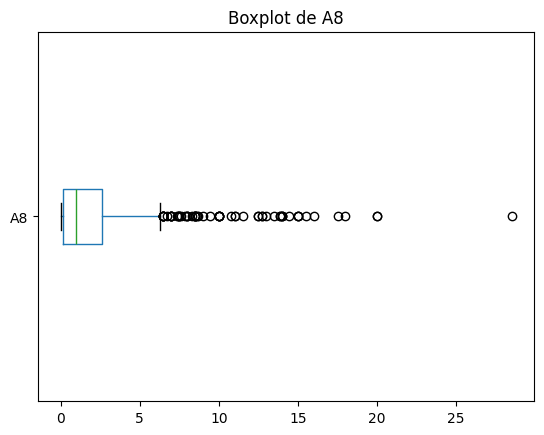

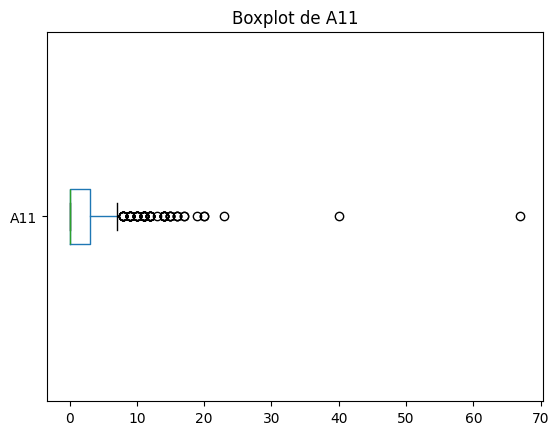

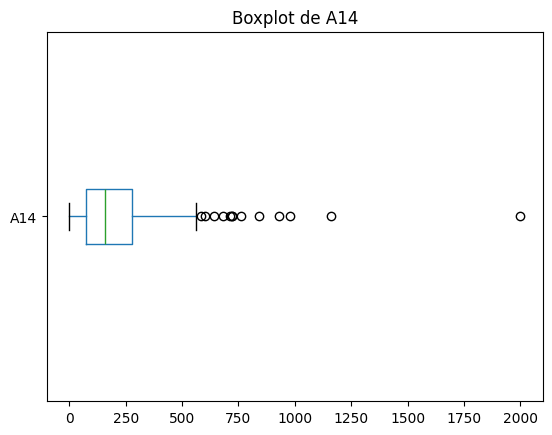

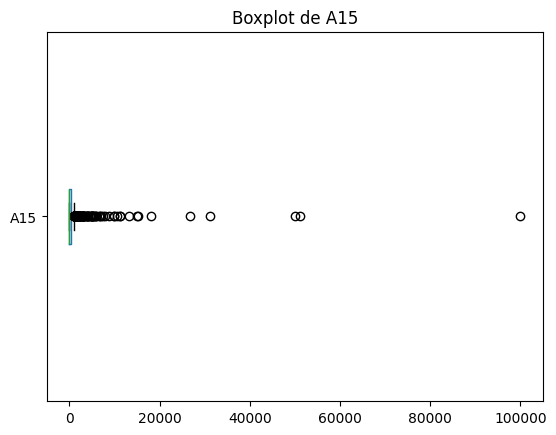

In [77]:
import matplotlib.pyplot as plt

for num in num_vars:
    plt.figure()
    df.boxplot(column=num, grid=False, vert=False)
    plt.title(f'Boxplot de {num}')
    plt.show()

En conclusión, ninguna variable es normal. La prueba de Kolmogorov-Smirnov rechaza la hipótesis nula en las seis y los histogramas se ven todos corridos hacia la derecha. La que más se parece a una campana es A2, con un sesgo de 1.15, y la más lejos es A15, con un sesgo de 13. En A11 y A15 casi todos los datos están pegados al cero con una cola bien larga.

Todas las variables tienen outliers y siempre por el lado de arriba, pero los casos más críticos son A15 y A11, que tienen mediana en 0 y unos poquitos registros disparados. A8 también muestra bastantes, mientras que en A2, A3 y A14 los puntos por fuera de los bigotes son pocos y no tan lejanos.

Viendo los valores no parecen errores de digitación sino casos reales, gente con ingresos o saldos muy por encima del resto. Por eso yo no los eliminaría, sino que aplicaría logaritmo o escalamiento robusto antes de entrenar.

## Paso 5: Análisis de variables cualitativas

Responda a las siguientes preguntas:

- ¿Cómo se comportan las variables categóricas?
- ¿Existen variables de alta cardinalidad?
- ¿Existen categorías atípicas?

In [78]:
cat_vars = df.select_dtypes(include=['object']).columns

for var in cat_vars:
    print(f'El conteo de la variable {var} es: \n {df[var].value_counts()} \n')

El conteo de la variable A1 es: 
 A1
b    468
a    210
Name: count, dtype: int64 

El conteo de la variable A4 es: 
 A4
u    519
y    163
l      2
Name: count, dtype: int64 

El conteo de la variable A5 es: 
 A5
g     519
p     163
gg      2
Name: count, dtype: int64 

El conteo de la variable A6 es: 
 A6
c     137
q      78
w      64
i      59
aa     54
ff     53
k      51
cc     41
x      38
m      38
d      30
e      25
j      10
r       3
Name: count, dtype: int64 

El conteo de la variable A7 es: 
 A7
v     399
h     138
bb     59
ff     57
j       8
z       8
dd      6
n       4
o       2
Name: count, dtype: int64 

El conteo de la variable A9 es: 
 A9
t    361
f    329
Name: count, dtype: int64 

El conteo de la variable A10 es: 
 A10
f    395
t    295
Name: count, dtype: int64 

El conteo de la variable A12 es: 
 A12
f    374
t    316
Name: count, dtype: int64 

El conteo de la variable A13 es: 
 A13
g    625
s     57
p      8
Name: count, dtype: int64 

El conteo de la variabl

In [79]:
pd.crosstab(df['A4'], df['A5'])

A5,g,gg,p
A4,,,
l,0,2,0
u,519,0,0
y,0,0,163


Las categóricas están casi todas desbalanceadas, menos A9, A10, A12 y A16, que quedan como mitad y mitad. Que A16 esté tan pareja (383 negados contra 307 aprobados) es bueno, porque no toca aplicar balanceo después. En A4, A5 y A13, en cambio, una sola categoría se lleva más del 75% de los registros.

De alta cardinalidad, frente al número de filas, no hay ninguna, pero A6 con 14 categorías y A7 con 9 sí hay que tenerlas en cuenta, porque con One-Hot Encoding esas dos solas dejarían como 23 columnas nuevas.

Categorías atípicas sí se encuentran varias: A4='l' y A5='gg' con 2 registros cada una, A13='p' con 8, y en A7 aparecen 'o' con 2, 'n' con 4 y 'dd' con 6. En A6 pasa lo mismo con 'r', que tiene 3. Esas categorías tan raras meten ruido, así que lo mejor sería juntarlas en una sola de "otros".

Otra cosa que sale en la tabla de contingencia es que A4 y A5 dicen exactamente lo mismo (u con g, y con p, l con gg), o sea que basta con dejar una de las dos.

## Paso 6: Análisis bivariado

Se va a suponer que con este archivo de datos se desea hacer un modelo de aprendizaje de máquina que prediga la vaariable **A15**.


Mediante análisis de gráficas responda las siguientes preguntas:

- ¿Cómo se relaciona cada una de las variables cuantitativas con la variable que se desea predecir?
- ¿Cómo se relaciona cada una de las variables cualitativas con la variable que se desea predecir?
- De acuerdo con estos análisis, ¿cuáles variables parecerían ser buenas predictoras, y cuáles no?

Como el archivo trae 16 columnas y no 15, la variable que se quiere predecir es la de aprobación del crédito, que según UCI es la última y que aquí quedó como A16.

In [80]:
df.groupby('A16')[num_vars].mean()

,A2,A3,A8,A11,A14,A15
A16,,,,,,
+,33.720492,5.904951,3.427899,4.605863,164.421927,2038.859935
-,29.808231,3.839948,1.257924,0.631854,199.699468,198.605744


<Figure size 640x480 with 0 Axes>

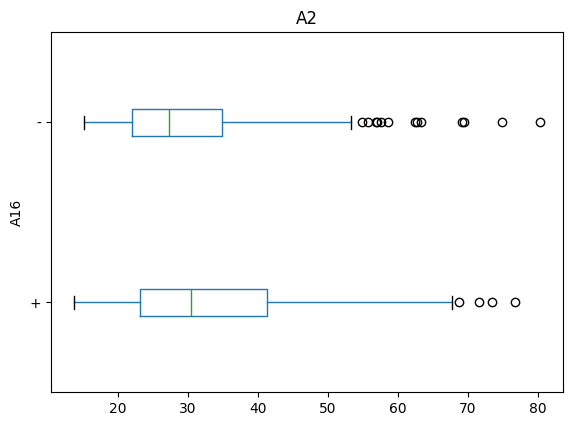

<Figure size 640x480 with 0 Axes>

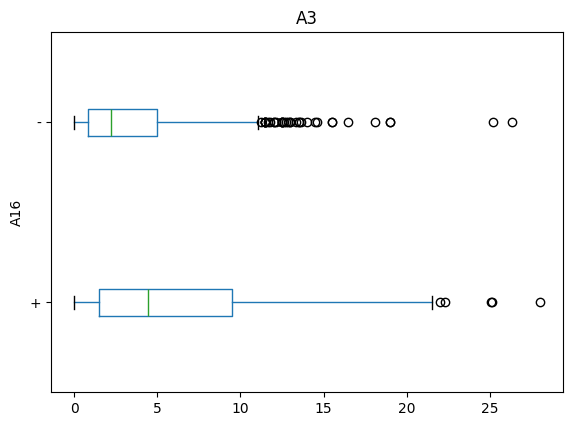

<Figure size 640x480 with 0 Axes>

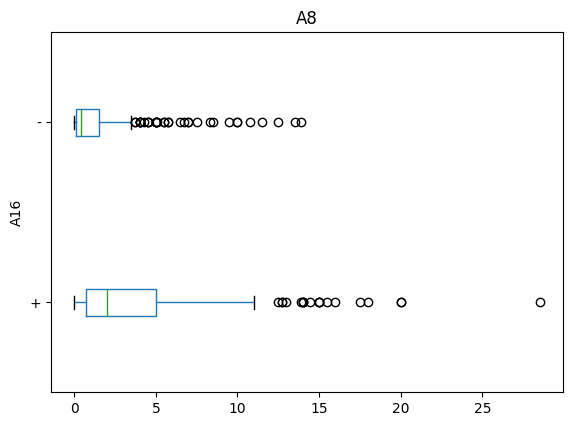

<Figure size 640x480 with 0 Axes>

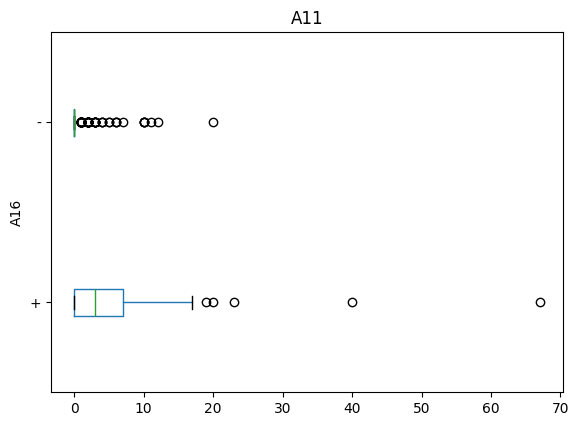

<Figure size 640x480 with 0 Axes>

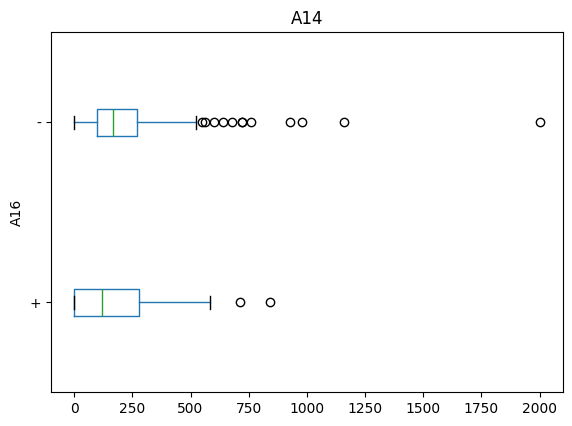

<Figure size 640x480 with 0 Axes>

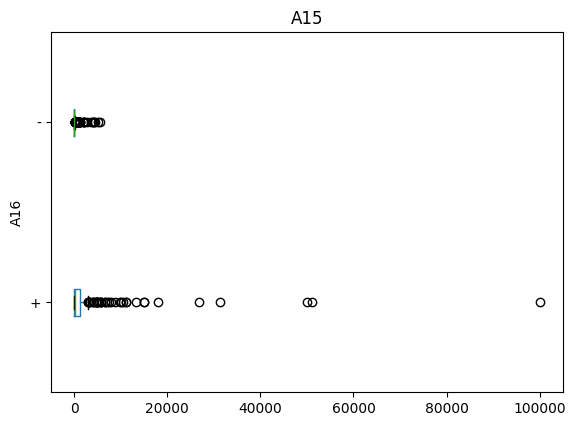

In [81]:
for var in num_vars:
    plt.figure()
    df.boxplot(column=var, by='A16', grid=False, vert=False)
    plt.suptitle('')
    plt.show()

<Axes: >

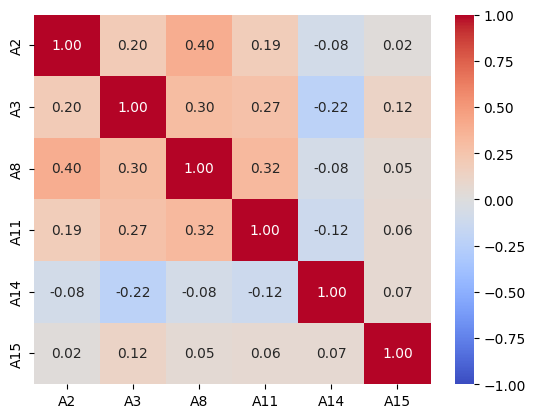

In [82]:
import seaborn as sns

corr = df.select_dtypes('number').corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)

In [83]:
pd.crosstab(df['A9'], df['A16'], normalize='index')

A16,+,-
A9,,
f,0.069909,0.930091
t,0.786704,0.213296


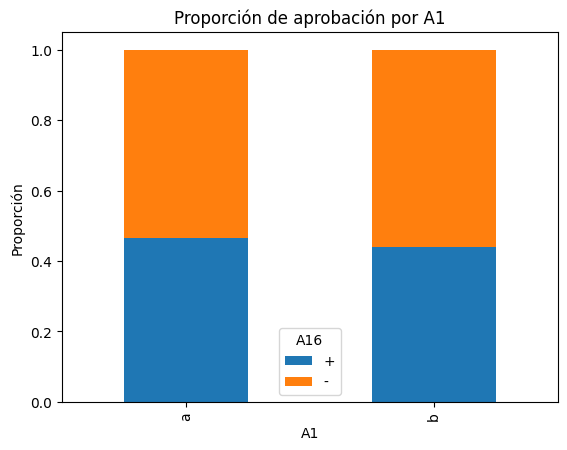

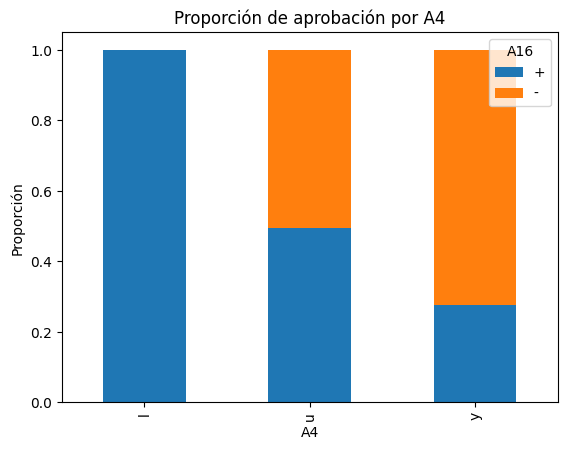

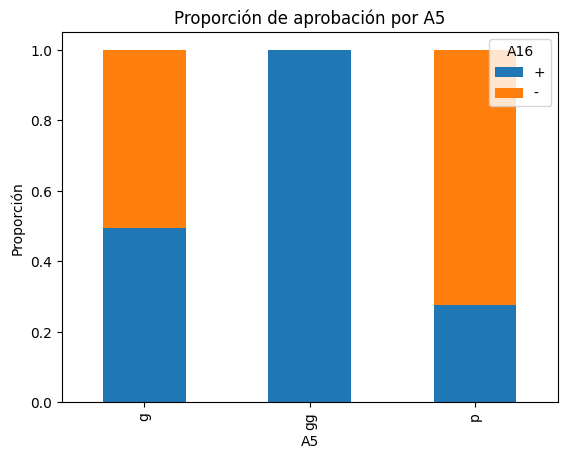

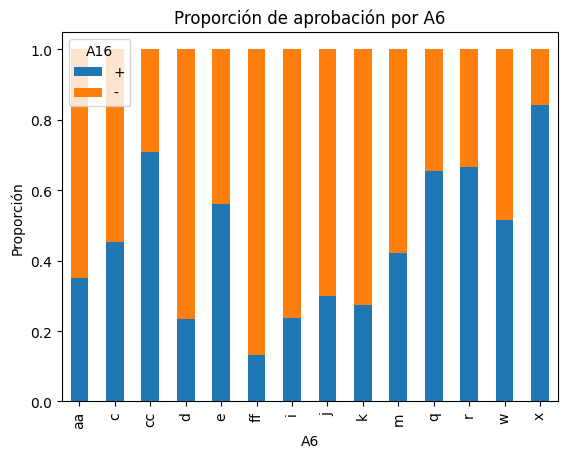

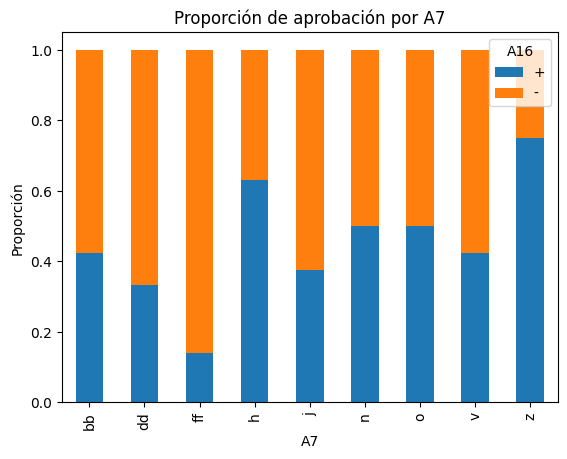

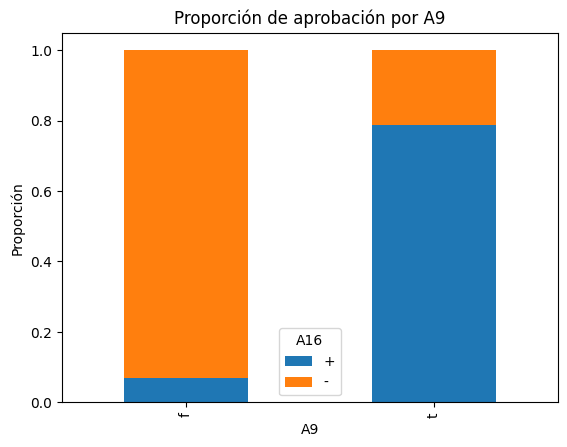

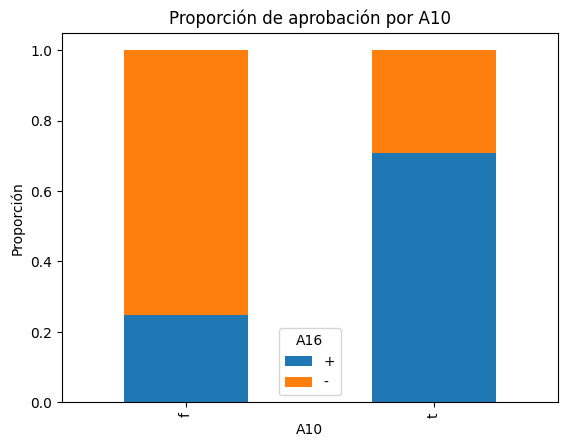

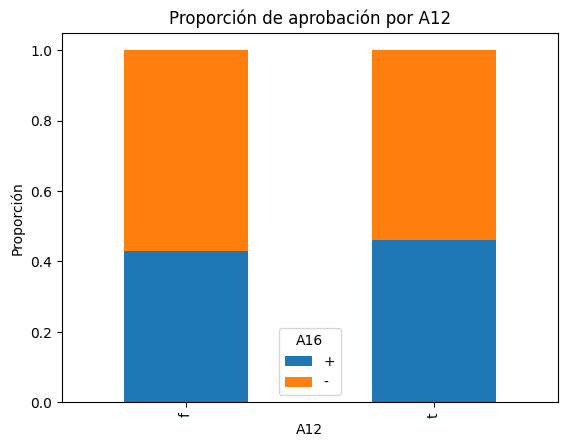

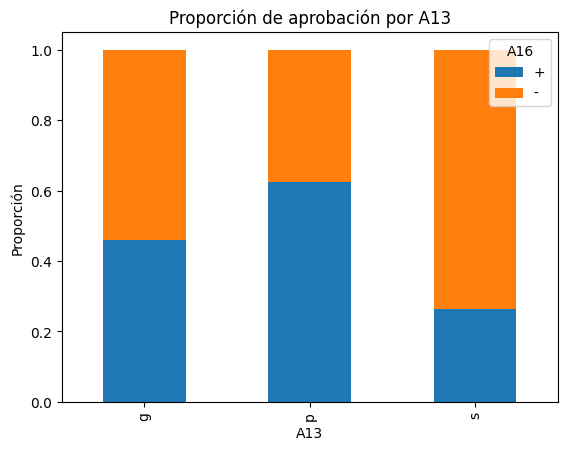

In [84]:
for var in cat_vars.drop('A16'):
    tabla = pd.crosstab(df[var], df['A16'], normalize='index')
    tabla.plot.bar(stacked=True)
    plt.title(f'Proporción de aprobación por {var}')
    plt.ylabel('Proporción')
    plt.show()

En las cuantitativas sí se ven diferencias entre grupos. La más clara es A11, que promedia 4.61 en los aprobados y 0.63 en los negados, o sea que los negados están casi todos en cero, y le sigue A8 con 3.43 contra 1.26. A15 también muestra una diferencia grande (2038 contra 198), pero hay que cogerla con pinzas porque está jalonada por los outliers del paso anterior. En A3 la diferencia es más chiquita pero se nota, y en A2 y A14 las cajas quedan casi encima una de otra. En el mapa de calor la correlación más alta es 0.40 entre A2 y A8, así que las variables son prácticamente independientes.

En las cualitativas la que más discrimina es A9, y por mucho: con `t` se aprueba el 78.7% de las solicitudes y con `f` apenas el 7%, esa sola casi separa las dos clases. Después va A10, con 70.8% contra 24.8%. A6, A7 y A13 también muestran diferencias, aunque en parte por categorías con muy pocos registros, como A6='x' que aprueba el 84%. En cambio A1 (46.7% contra 44.0%) y A12 (46.2% contra 43.0%) quedan con las barras casi del mismo tamaño.

Con eso, las que parecen buenas predictoras son A9 y A10, y después A11, A8, A15, A3 y A6. Las que no aportan casi nada son A1, A12 y A14, y de A4 y A5 toca dejar solo una porque son la misma información. A2, A7 y A13 quedan a medio camino, valdría la pena probarlas en el modelo antes de decidir. Eso sí, antes de entrenar hay que arreglar lo de los pasos anteriores: imputar los nulos, agrupar las categorías raras de A6 y A7 y escalar bien las variables sesgadas.